# Red Neuronal Convolucional (CNN) - Clasificador de Animales
### Clases: Ranas, PÃ¡jaros, Ballenas, Changos, AraÃ±as
### ImÃ¡genes: 28x28 pÃ­xeles, RGB (Color), 10,000 por clase

# 1. Importar LibrerÃ­as

In [119]:
import numpy as np
import os
import re
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.14.0


# 2. Cargar ImÃ¡genes del Dataset

**Estructura esperada de carpetas:**
```
Dataset_Final/
â”œâ”€â”€ ranas/       (10,000 imÃ¡genes)
â”œâ”€â”€ pajaros/     (10,000 imÃ¡genes)
â”œâ”€â”€ ballenas/    (10,000 imÃ¡genes)
â”œâ”€â”€ changos/     (10,000 imÃ¡genes)
â””â”€â”€ araÃ±as/      (10,000 imÃ¡genes)
```

In [120]:
# Ruta a la carpeta principal del dataset
dirname = os.path.join(os.getcwd(), 'dataset')
imgpath = dirname + os.sep

images = []
labels = []

# Nombres de las clases (deben coincidir EXACTAMENTE con los nombres de las carpetas)
clases_nombres = ['ranas', 'pajaros', 'ballenas', 'changos', 'aranas']

print("Leyendo imÃ¡genes de:", imgpath)
print("-" * 50)

dircount = []  # guardarÃ¡ cuÃ¡ntas imÃ¡genes tiene cada clase

for idx, clase in enumerate(clases_nombres):
    folder = os.path.join(imgpath, clase)
    
    if not os.path.exists(folder):
        print(f"âš ï¸  ALERTA: No se encontrÃ³ la carpeta '{clase}' en {folder}")
        continue
    
    contador = 0
    for filename in os.listdir(folder):
        if re.search(r"\.(jpg|jpeg|png|bmp)$", filename, re.IGNORECASE):
            filepath = os.path.join(folder, filename)
            image = cv2.imread(filepath, cv2.IMREAD_COLOR)
            if image is not None:
                # Nos aseguramos que todas sean 28x28
                image = cv2.resize(image, (28, 28))
                images.append(image)
                labels.append(idx)
                contador += 1
    
    dircount.append(contador)
    print(f"Clase {idx} - {clase}: {contador} imÃ¡genes cargadas")

print("-" * 50)
print(f'âœ… Total de imÃ¡genes cargadas: {len(images)}')

Leyendo imÃ¡genes de: c:\Users\Legion\OneDrive\Escritorio\CNN-RGB\dataset\
--------------------------------------------------
Clase 0 - ranas: 14511 imÃ¡genes cargadas
Clase 1 - pajaros: 14495 imÃ¡genes cargadas
Clase 2 - ballenas: 14376 imÃ¡genes cargadas
Clase 3 - changos: 14448 imÃ¡genes cargadas
Clase 4 - aranas: 14372 imÃ¡genes cargadas
--------------------------------------------------
âœ… Total de imÃ¡genes cargadas: 72202


# 3. Verificar Equilibrio del Dataset

=== EQUILIBRIO DEL DATASET ===
----------------------------------------
Clase 0 | ranas      |  14511 imÃ¡genes | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
Clase 1 | pajaros    |  14495 imÃ¡genes | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
Clase 2 | ballenas   |  14376 imÃ¡genes | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
Clase 3 | changos    |  14448 imÃ¡genes | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
Clase 4 | aranas     |  14372 imÃ¡genes | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
----------------------------------------
Total: 72202 imÃ¡genes
âš ï¸  Dataset DESBALANCEADO (mÃ­n: 14372, mÃ¡x: 14511)


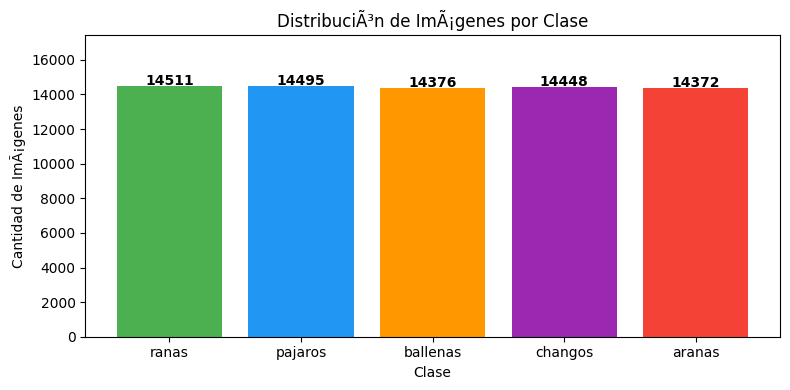

In [121]:
print("=== EQUILIBRIO DEL DATASET ===")
print("-" * 40)
for i, (clase, cantidad) in enumerate(zip(clases_nombres, dircount)):
    barra = 'â–ˆ' * (cantidad // 500)
    print(f"Clase {i} | {clase:<10} | {cantidad:>6} imÃ¡genes | {barra}")

print("-" * 40)
total = sum(dircount)
print(f"Total: {total} imÃ¡genes")

# Verificar si estÃ¡ balanceado
min_clase = min(dircount)
max_clase = max(dircount)
if max_clase - min_clase <= 100:
    print("âœ… Dataset BALANCEADO (diferencia <= 100 imÃ¡genes entre clases)")
else:
    print(f"âš ï¸  Dataset DESBALANCEADO (mÃ­n: {min_clase}, mÃ¡x: {max_clase})")

# GrÃ¡fica de equilibrio
plt.figure(figsize=(8, 4))
plt.bar(clases_nombres, dircount, color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336'])
plt.title('DistribuciÃ³n de ImÃ¡genes por Clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de ImÃ¡genes')
plt.ylim(0, max(dircount) * 1.2)
for i, v in enumerate(dircount):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Convertir a Matrices Numpy

In [122]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8)

# Reshape: (N, 28, 28, 3)  [3 = canales RGB/color]
X = X.reshape(X.shape[0], 28, 28, 3)

classes = np.unique(y)
nClasses = len(classes)

print(f'Forma de X (imÃ¡genes): {X.shape}')
print(f'Forma de y (etiquetas): {y.shape}')
print(f'NÃºmero de clases: {nClasses}')
print(f'Clases: {list(zip(classes, clases_nombres))}')

Forma de X (imÃ¡genes): (72202, 28, 28, 3)
Forma de y (etiquetas): (72202,)
NÃºmero de clases: 5
Clases: [(np.int64(0), 'ranas'), (np.int64(1), 'pajaros'), (np.int64(2), 'ballenas'), (np.int64(3), 'changos'), (np.int64(4), 'aranas')]


# 5. Dividir en Sets de Entrenamiento y Prueba

In [123]:
# 80% entrenamiento, 20% prueba
train_X, test_X, train_Y, test_Y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Set de Entrenamiento: {train_X.shape}  |  Etiquetas: {train_Y.shape}')
print(f'Set de Prueba:        {test_X.shape}   |  Etiquetas: {test_Y.shape}')

Set de Entrenamiento: (57761, 28, 28, 3)  |  Etiquetas: (57761,)
Set de Prueba:        (14441, 28, 28, 3)   |  Etiquetas: (14441,)


# 6. Visualizar Ejemplos del Dataset

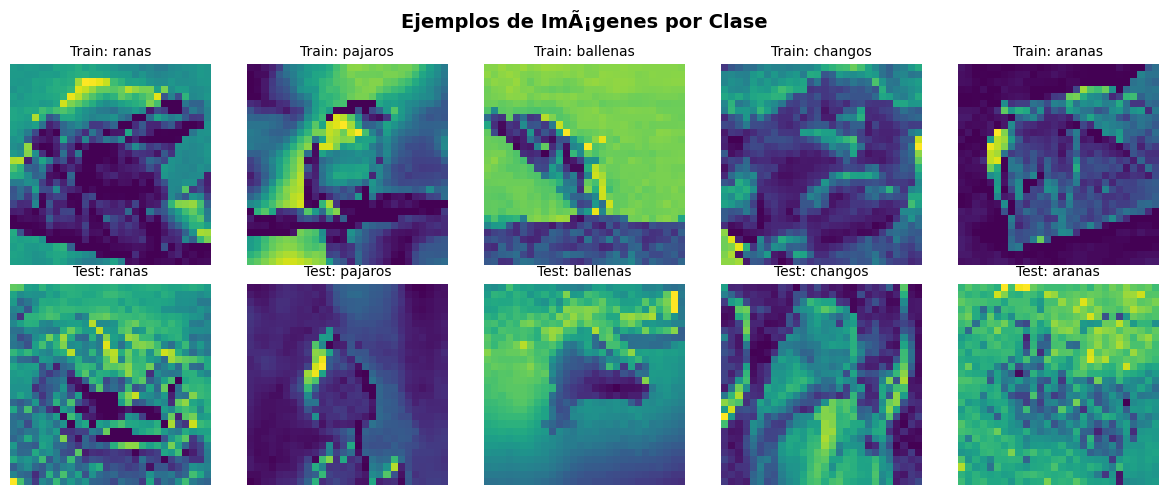

In [124]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Ejemplos de ImÃ¡genes por Clase', fontsize=14, fontweight='bold')

for clase_idx in range(nClasses):
    idx = np.where(train_Y == clase_idx)[0][0]
    
    axes[0, clase_idx].imshow(train_X[idx, :, :, 0])
    axes[0, clase_idx].set_title(f'Train: {clases_nombres[clase_idx]}', fontsize=10)
    axes[0, clase_idx].axis('off')
    
    idx2 = np.where(test_Y == clase_idx)[0][0]
    axes[1, clase_idx].imshow(test_X[idx2, :, :, 0])
    axes[1, clase_idx].set_title(f'Test: {clases_nombres[clase_idx]}', fontsize=10)
    axes[1, clase_idx].axis('off')

plt.tight_layout()
plt.show()

# 7. Preprocesar las ImÃ¡genes (NormalizaciÃ³n)

In [125]:
# Convertir a float y normalizar entre 0 y 1
train_X = train_X.astype('float32') / 255.0
test_X  = test_X.astype('float32')  / 255.0

print(f'Rango de valores - MÃ­n: {train_X.min():.2f}, MÃ¡x: {train_X.max():.2f}')
print('âœ… ImÃ¡genes normalizadas correctamente')

Rango de valores - MÃ­n: 0.00, MÃ¡x: 1.00
âœ… ImÃ¡genes normalizadas correctamente


# 8. One-Hot Encoding de Etiquetas

In [126]:
train_Y_one_hot = to_categorical(train_Y, num_classes=nClasses)
test_Y_one_hot  = to_categorical(test_Y,  num_classes=nClasses)

print('Etiqueta original (train_Y[0]):', train_Y[0], '->', clases_nombres[train_Y[0]])
print('One-hot encoding:', train_Y_one_hot[0])

Etiqueta original (train_Y[0]): 4 -> aranas
One-hot encoding: [0. 0. 0. 0. 1.]


# 9. Crear Set de ValidaciÃ³n

In [127]:
# Dividir el set de entrenamiento en entrenamiento (80%) y validaciÃ³n (20%)
train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, train_Y_one_hot, test_size=0.2, random_state=48
)

print(f'Entrenamiento: {train_X.shape}  |  Labels: {train_label.shape}')
print(f'ValidaciÃ³n:    {valid_X.shape}   |  Labels: {valid_label.shape}')
print(f'Prueba:        {test_X.shape}    |  Labels: {test_Y_one_hot.shape}')

Entrenamiento: (46208, 28, 28, 3)  |  Labels: (46208, 5)
ValidaciÃ³n:    (11553, 28, 28, 3)   |  Labels: (11553, 5)
Prueba:        (14441, 28, 28, 3)    |  Labels: (14441, 5)


# 10. Crear el Modelo CNN

**Arquitectura:** 2 capas convolucionales + capas densas para clasificaciÃ³n

In [128]:
# ParÃ¡metros de entrenamiento
INIT_LR    = 1e-3   # Learning rate inicial
epochs     = 40     # 40 Ã©pocas para mejor precisiÃ³n
batch_size = 32     # ImÃ¡genes por lote

In [129]:
# =============================================
#   ARQUITECTURA CNN - 2 CAPAS CONVOLUCIONALES
# =============================================
sport_model = Sequential(name='CNN_Animales')

# --- CAPA CONVOLUCIONAL 1 ---
sport_model.add(Conv2D(32, kernel_size=(3, 3), activation='linear',
                       padding='same', input_shape=(28, 28, 3)))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.3))

# --- CAPA CONVOLUCIONAL 2 ---
sport_model.add(Conv2D(64, kernel_size=(3, 3), activation='linear', padding='same'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.3))

# --- CAPAS DENSAS (ClasificaciÃ³n final) ---
sport_model.add(Flatten())
sport_model.add(Dense(128, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))
sport_model.add(Dense(nClasses, activation='softmax'))

sport_model.summary()

c:\Users\Legion\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Legion\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "CNN_Animales"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,573 (1.61 MB)

 Trainable params: 421,573 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

# 11. Compilar el Modelo

In [130]:
sport_model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
    metrics=['accuracy']
)
print('âœ… Modelo compilado correctamente')

âœ… Modelo compilado correctamente


# 12. Entrenar el Modelo

> â³ Este paso puede tardar varios minutos dependiendo de tu CPU/GPU.

In [131]:
sport_train = sport_model.fit(
    train_X, train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label)
)

Epoch 1/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.8859 - loss: 0.3148 - val_accuracy: 0.9881 - val_loss: 0.0430
Epoch 2/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.9815 - loss: 0.0608 - val_accuracy: 0.9969 - val_loss: 0.0126
Epoch 3/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9871 - loss: 0.0419 - val_accuracy: 0.9953 - val_loss: 0.0127
Epoch 4/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9966 - val_loss: 0.0091
Epoch 5/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9906 - loss: 0.0290 - val_accuracy: 0.9996 - val_loss: 0.0017
Epoch 6/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.9933 - loss: 0.0216 - val_accuracy: 0.9980 - val_loss: 0.0054
Epoch 7/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9937 - loss: 0.0201 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 8/40
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9934 -

# 13. Guardar el Modelo Entrenado

In [132]:
sport_model.save("modelo_cnn.h5")
print("âœ… Modelo guardado como: modelo_cnn.h5")

âœ… Modelo guardado como: modelo_cnn.h5


# 14. Evaluar el Modelo

In [133]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)
print(f'\nPÃ©rdida (Loss):   {test_eval[0]:.4f}')
print(f'PrecisiÃ³n (Acc):  {test_eval[1]*100:.2f}%')

452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9994 - loss: 0.0045

PÃ©rdida (Loss):   0.0045
PrecisiÃ³n (Acc):  99.94%


# 15. GrÃ¡ficas de Entrenamiento

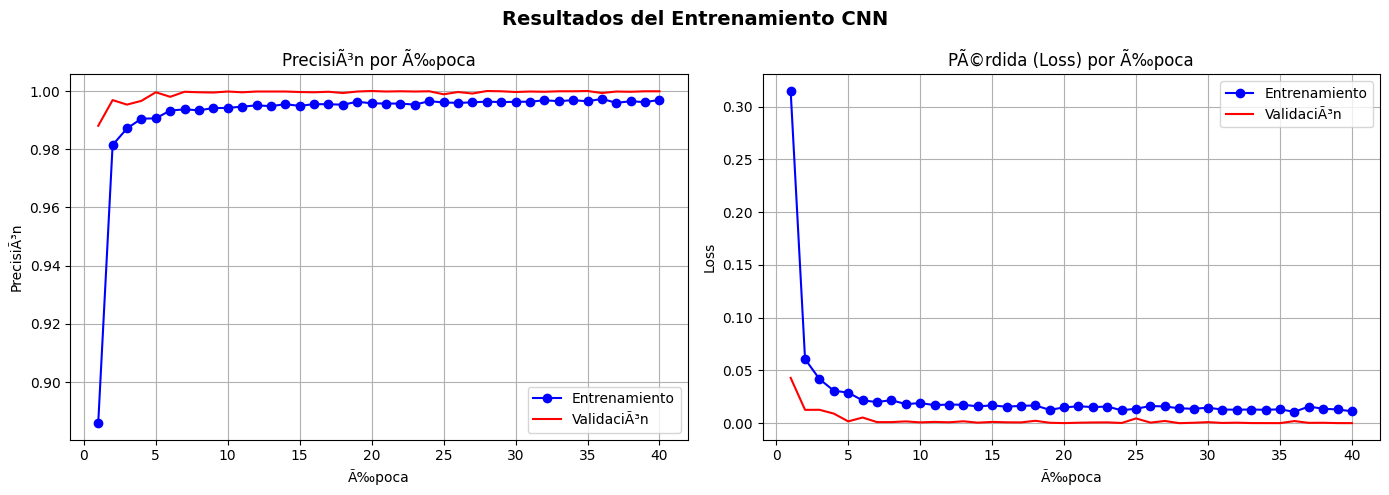

In [134]:
accuracy     = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss         = sport_train.history['loss']
val_loss     = sport_train.history['val_loss']
epocas_rango = range(1, len(accuracy) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epocas_rango, accuracy,     'bo-', label='Entrenamiento')
ax1.plot(epocas_rango, val_accuracy, 'r-',  label='ValidaciÃ³n')
ax1.set_title('PrecisiÃ³n por Ã‰poca')
ax1.set_xlabel('Ã‰poca')
ax1.set_ylabel('PrecisiÃ³n')
ax1.legend()
ax1.grid(True)

ax2.plot(epocas_rango, loss,     'bo-', label='Entrenamiento')
ax2.plot(epocas_rango, val_loss, 'r-',  label='ValidaciÃ³n')
ax2.set_title('PÃ©rdida (Loss) por Ã‰poca')
ax2.set_xlabel('Ã‰poca')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Resultados del Entrenamiento CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 16. Reporte de ClasificaciÃ³n

In [135]:
predicted_probs   = sport_model.predict(test_X)
predicted_classes = np.argmax(predicted_probs, axis=1)

print("=== REPORTE DE CLASIFICACIÃ“N ===")
print(classification_report(test_Y, predicted_classes, target_names=clases_nombres))

452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
=== REPORTE DE CLASIFICACIÃ“N ===
              precision    recall  f1-score   support

       ranas       1.00      1.00      1.00      2902
     pajaros       1.00      1.00      1.00      2899
    ballenas       1.00      1.00      1.00      2875
     changos       1.00      1.00      1.00      2890
      aranas       1.00      1.00      1.00      2875

    accuracy                           1.00     14441
   macro avg       1.00      1.00      1.00     14441
weighted avg       1.00      1.00      1.00     14441



# 17. Ver Aciertos y Errores

Correctas:   14432
Incorrectas: 9


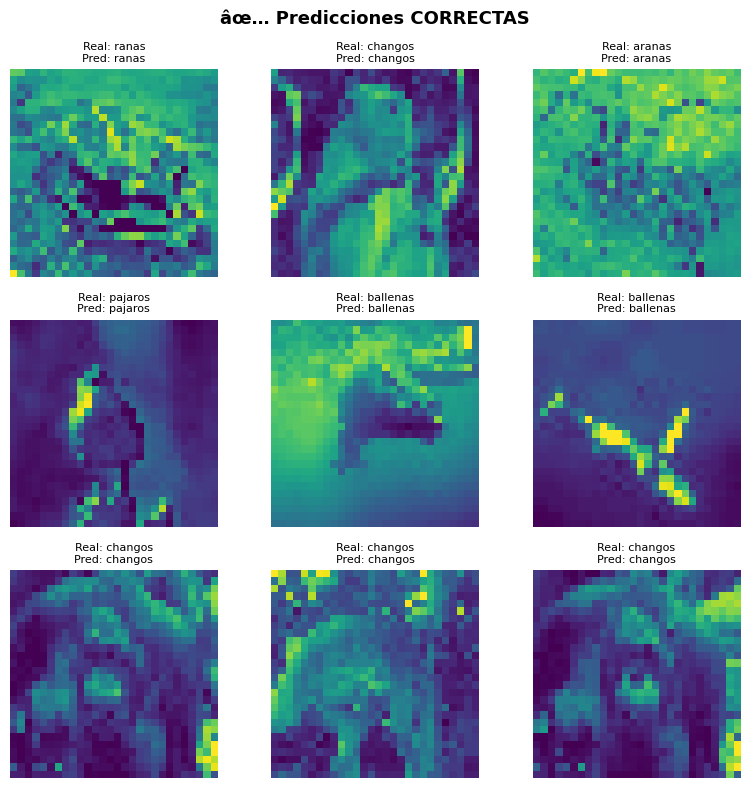

C:\Users\Legion\AppData\Local\Temp\ipykernel_27340\4076276043.py:26: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Legion\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


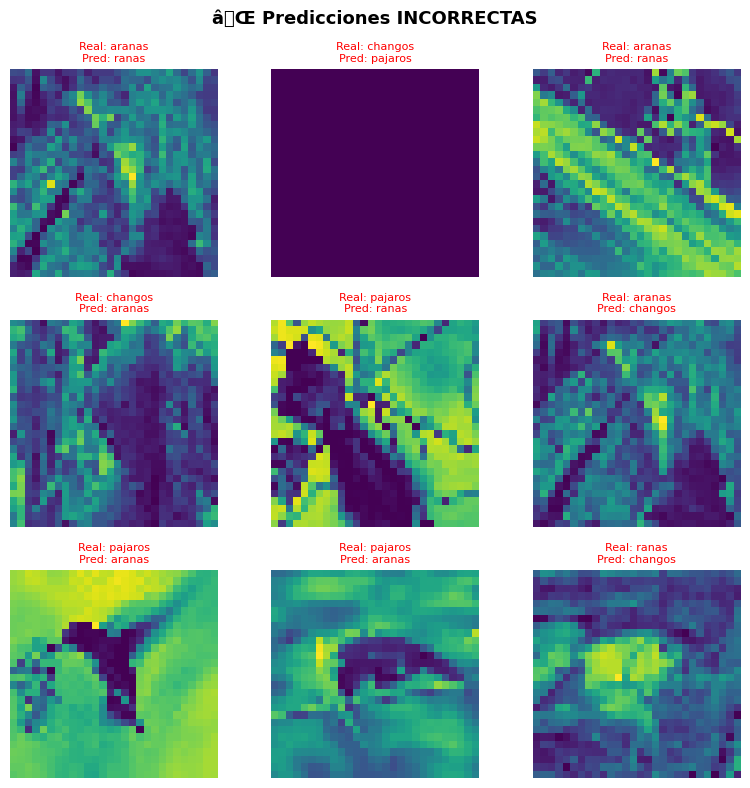

In [136]:
correct   = np.where(predicted_classes == test_Y)[0]
incorrect = np.where(predicted_classes != test_Y)[0]
print(f'Correctas:   {len(correct)}')
print(f'Incorrectas: {len(incorrect)}')

# Mostrar 9 aciertos
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('âœ… Predicciones CORRECTAS', fontsize=13, fontweight='bold')
for i, idx in enumerate(correct[:9]):
    ax = axes[i // 3, i % 3]
    ax.imshow(test_X[idx, :, :, 0])
    ax.set_title(f'Real: {clases_nombres[test_Y[idx]]}\nPred: {clases_nombres[predicted_classes[idx]]}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Mostrar 9 errores
if len(incorrect) > 0:
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle('âŒ Predicciones INCORRECTAS', fontsize=13, fontweight='bold')
    for i, idx in enumerate(incorrect[:9]):
        ax = axes[i // 3, i % 3]
        ax.imshow(test_X[idx, :, :, 0])
        ax.set_title(f'Real: {clases_nombres[test_Y[idx]]}\nPred: {clases_nombres[predicted_classes[idx]]}', fontsize=8, color='red')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

---
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
# ðŸ”„ DESDE AQUÃ PUEDES EMPEZAR SIN REENTRENAR
# â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•
### Si reinicias el kernel, ejecuta solo las celdas 18 y 19

# 18. Cargar Modelo Guardado
### â–¶ï¸ Ejecuta esta celda PRIMERO si reinicias el kernel

In [137]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Cargamos el modelo ya entrenado
sport_model = load_model('modelo_cnn.h5')

# Nombres de clases (siempre deben estar definidos)
clases_nombres = ['ranas', 'pajaros', 'ballenas', 'changos', 'aranas']

print('âœ… Modelo cargado correctamente')
print('âœ… Listo para identificar animales â€” ejecuta la celda 19')

âœ… Modelo cargado correctamente
âœ… Listo para identificar animales â€” ejecuta la celda 19


# 19. ðŸ” Identificar una Imagen Nueva
### â–¶ï¸ Ejecuta esta celda cada vez que quieras identificar un animal
> Se abrirÃ¡ una ventana para que **selecciones cualquier imagen de tu PC**

“‚ 65 imagen(es) seleccionada(s)


ðŸ” Procesando imagen 1: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana2.jpg


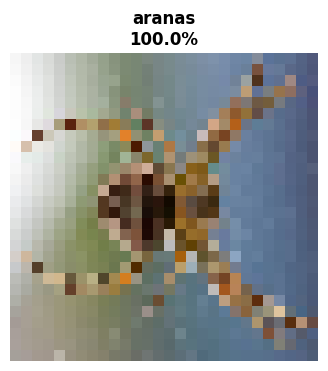

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 2: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana3.jpg


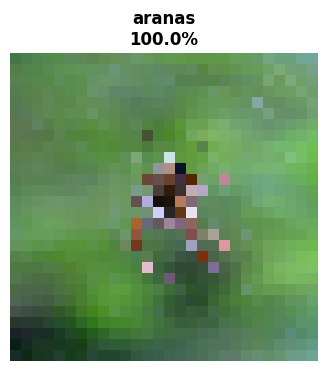

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 3: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana4.jpg


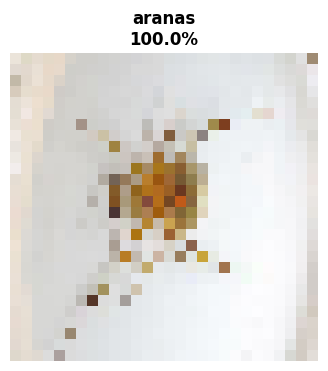

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 4: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana5.jpg


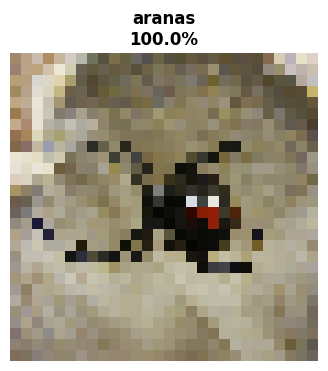

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 5: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana6.jpg


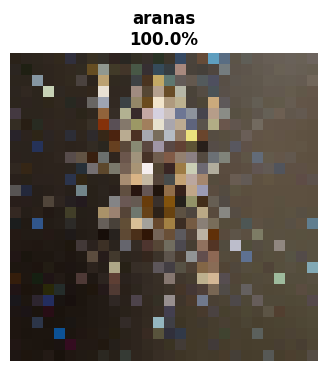

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 6: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana7.jpg


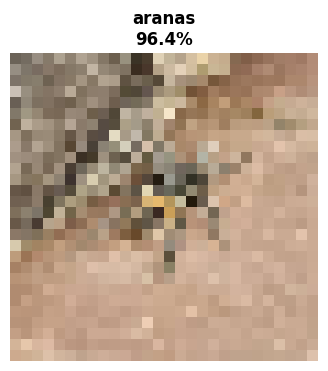

Resultado: ARANAS (96.4%)
   Probabilidades:
   ranas     :   3.6% â–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :  96.4% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 7: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana8.jpg


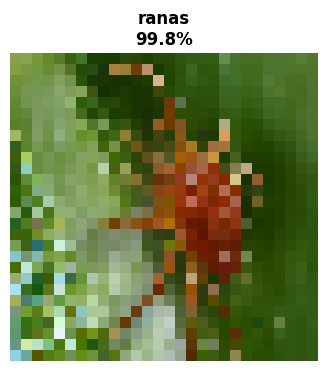

Resultado: RANAS (99.8%)
   Probabilidades:
   ranas     :  99.8% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.1% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.2% 

ðŸ” Procesando imagen 8: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana9.jpg


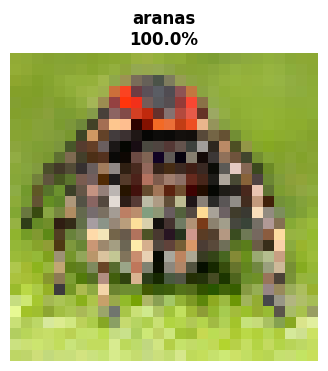

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 9: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana10.jpg


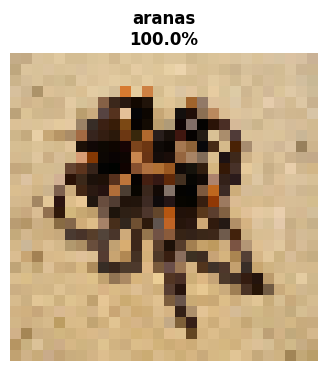

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 10: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana11.jpg


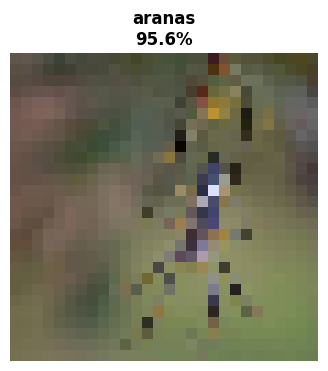

Resultado: ARANAS (95.6%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   4.3% â–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :  95.6% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 11: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana12.jpg


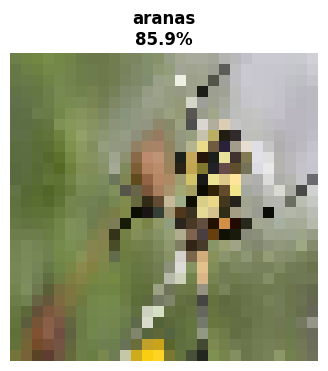

Resultado: ARANAS (85.9%)
   Probabilidades:
   ranas     :   0.2% 
   pajaros   :  13.9% â–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :  85.9% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 12: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana13.jpg


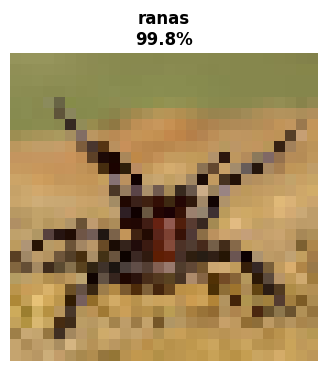

Resultado: RANAS (99.8%)
   Probabilidades:
   ranas     :  99.8% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.2% 

ðŸ” Procesando imagen 13: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana14.jpg


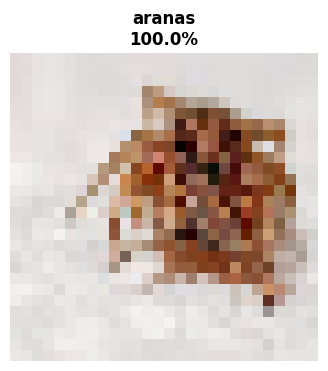

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 14: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/arana15.png


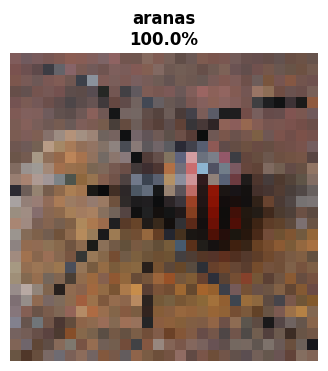

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 15: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena.jpg


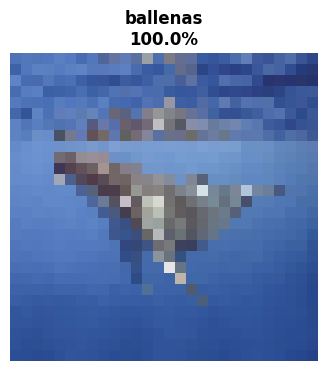

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 16: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena2.jpg


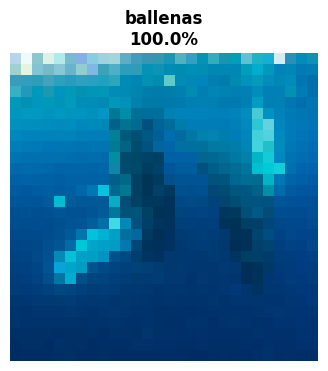

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 17: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena3.jpg


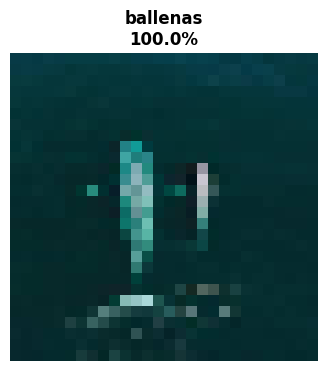

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 18: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena4.jpg


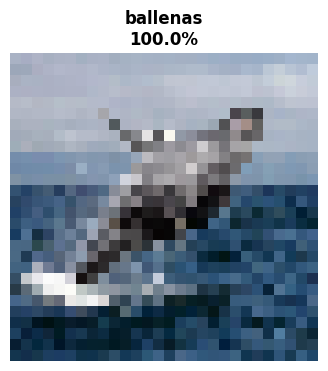

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 19: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena5.jpg


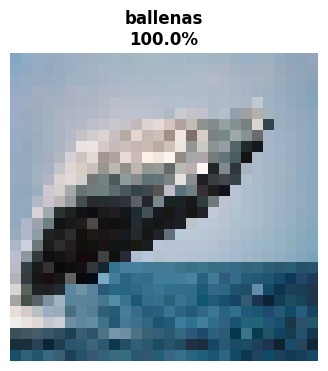

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 20: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena6.jpg


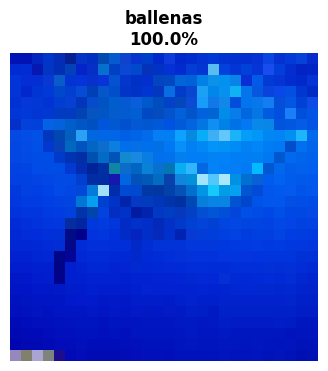

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 21: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena7.jpg


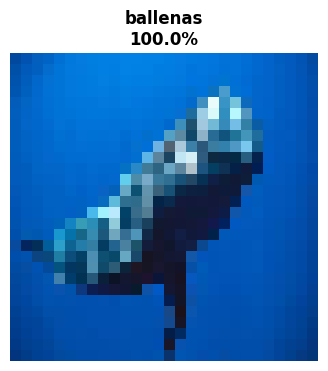

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 22: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena8.jpg


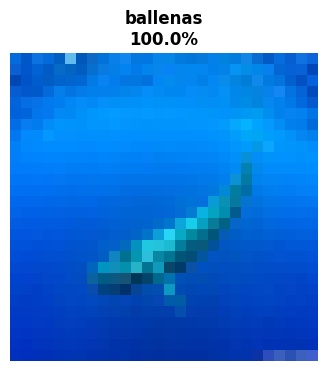

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 23: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena9.jpg


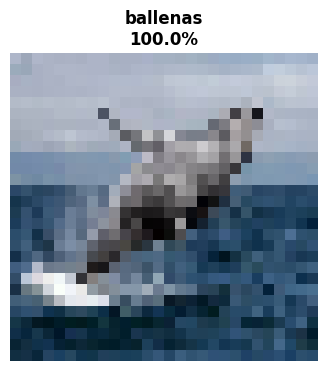

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 24: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena10.jpg


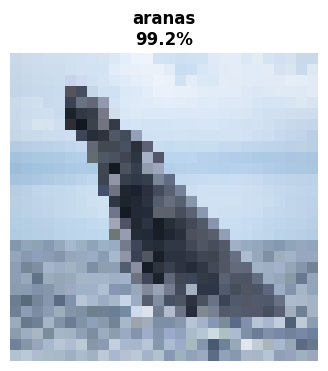

Resultado: ARANAS (99.2%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.6% 
   ballenas  :   0.2% 
   changos   :   0.0% 
   aranas    :  99.2% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 25: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena11.jpg


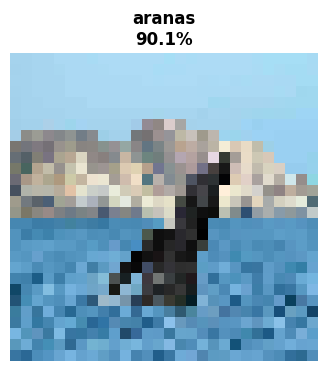

Resultado: ARANAS (90.1%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   9.9% â–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :  90.1% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 26: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/ballena12.jpg


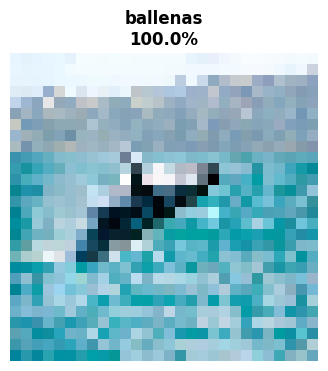

Resultado: BALLENAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 27: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/Captura de pantalla 2026-04-29 131114.png


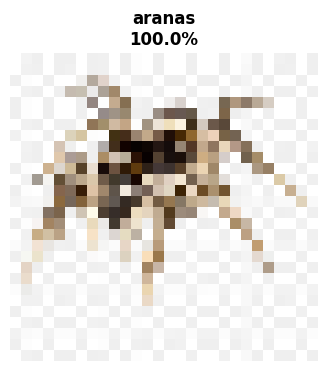

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 28: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/Captura de pantalla 2026-05-04 181249.png


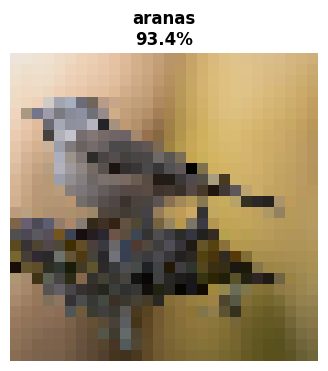

Resultado: ARANAS (93.4%)
   Probabilidades:
   ranas     :   5.6% â–ˆ
   pajaros   :   1.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :  93.4% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 29: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/Captura de pantalla 2026-05-07 221352.png


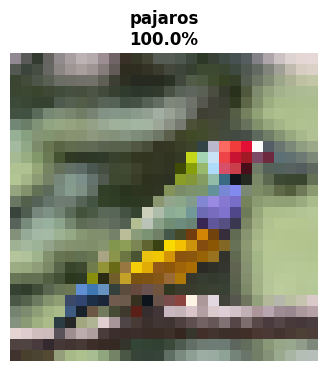

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 30: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango2.png


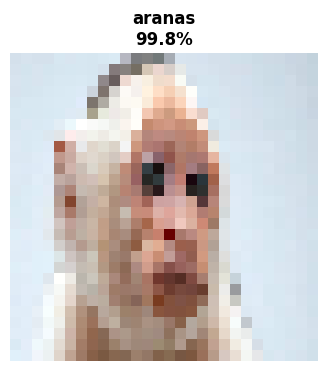

Resultado: ARANAS (99.8%)
   Probabilidades:
   ranas     :   0.1% 
   pajaros   :   0.1% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :  99.8% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 31: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango3.jpg


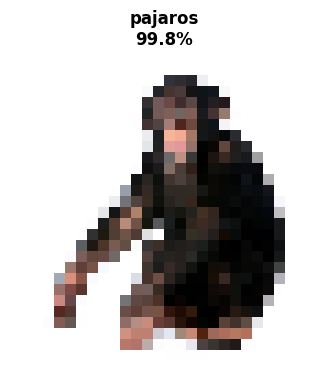

Resultado: PAJAROS (99.8%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :  99.8% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.2% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 32: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango4.jpg


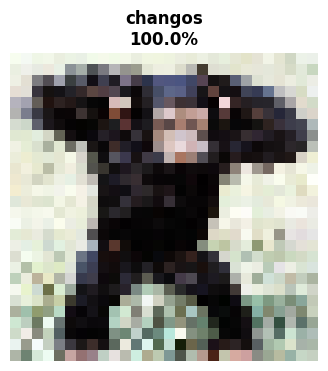

Resultado: CHANGOS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   aranas    :   0.0% 

ðŸ” Procesando imagen 33: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango7.jpg


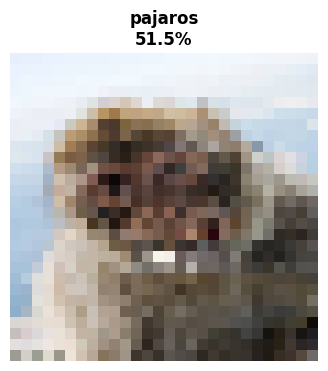

Resultado: PAJAROS (51.5%)
   Probabilidades:
   ranas     :   0.4% 
   pajaros   :  51.5% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :  48.1% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 34: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango8.jpg


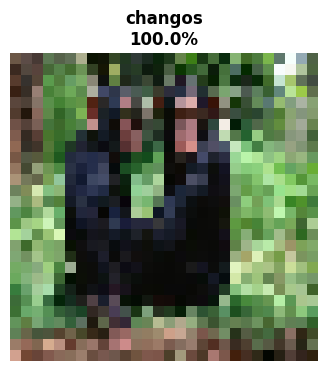

Resultado: CHANGOS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   aranas    :   0.0% 

ðŸ” Procesando imagen 35: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango9.jpg


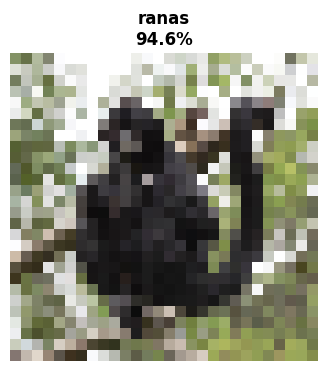

Resultado: RANAS (94.6%)
   Probabilidades:
   ranas     :  94.6% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   5.4% â–ˆ
   aranas    :   0.0% 

ðŸ” Procesando imagen 36: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango10.jpg


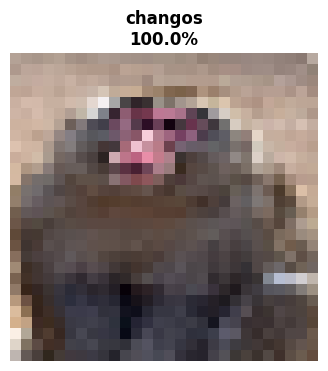

Resultado: CHANGOS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   aranas    :   0.0% 

ðŸ” Procesando imagen 37: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango11.jpg


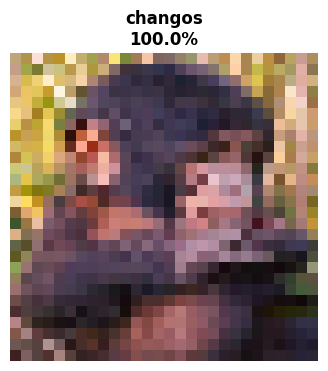

Resultado: CHANGOS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   aranas    :   0.0% 

ðŸ” Procesando imagen 38: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango12.jpg


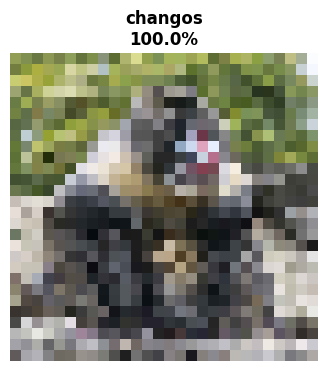

Resultado: CHANGOS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   aranas    :   0.0% 

ðŸ” Procesando imagen 39: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango13.jpg


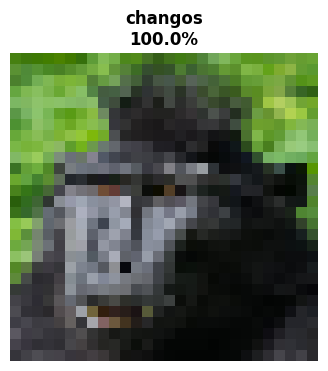

Resultado: CHANGOS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   aranas    :   0.0% 

ðŸ” Procesando imagen 40: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/chango14.jpg


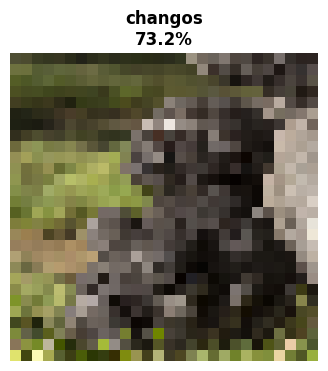

Resultado: CHANGOS (73.2%)
   Probabilidades:
   ranas     :  26.8% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :  73.2% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   aranas    :   0.0% 

ðŸ” Procesando imagen 41: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro1.jpg


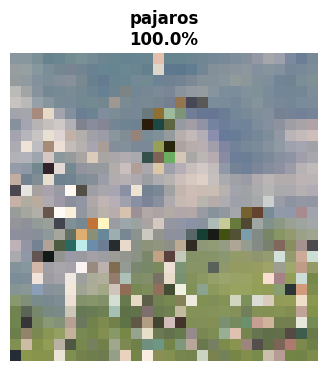

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 42: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro2.jpg


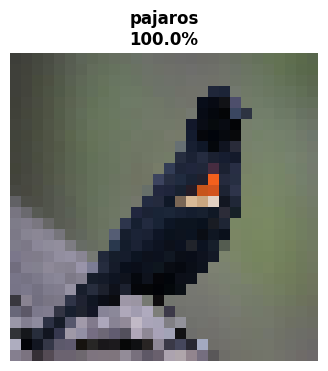

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 43: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro3.jpg


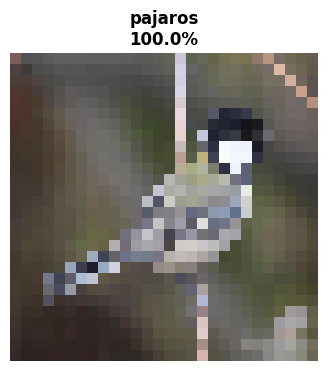

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 44: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro4.jpg


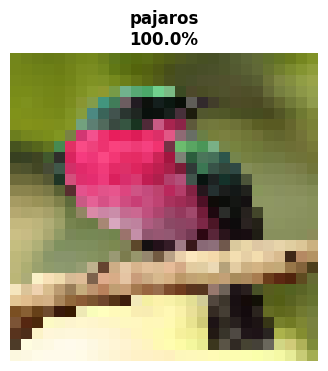

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 45: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro5.jpg


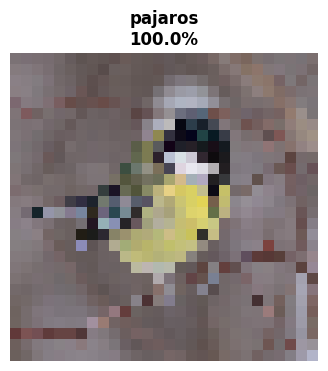

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 46: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro6.jpg


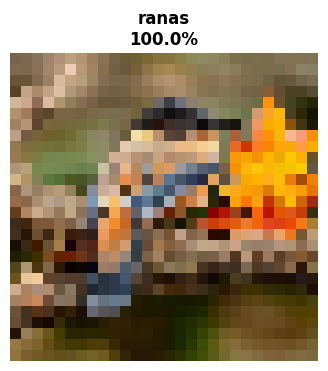

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 47: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro7.jpg


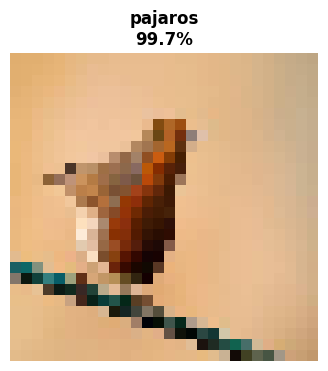

Resultado: PAJAROS (99.7%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :  99.7% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.3% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 48: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro8.jpg


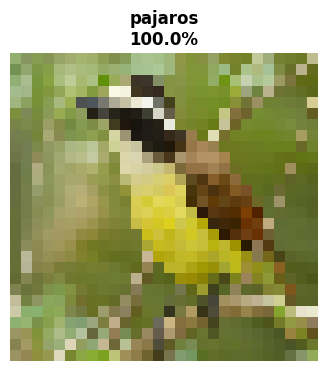

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 49: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro9.jpg


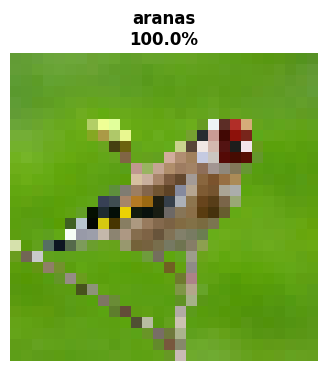

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 50: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro10.jpg


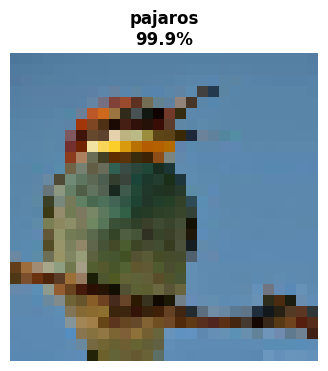

Resultado: PAJAROS (99.9%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :  99.9% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.1% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 51: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro11.jpg


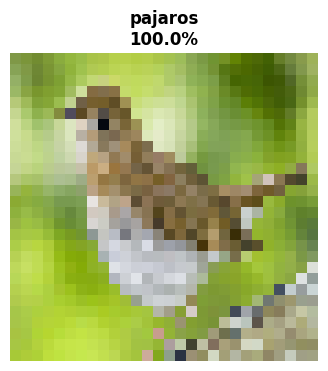

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 52: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/pajaro12.jpg


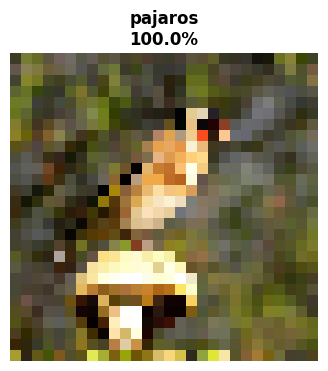

Resultado: PAJAROS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 53: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana.jpg


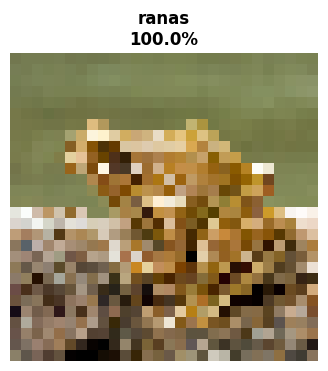

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 54: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana2.jpg


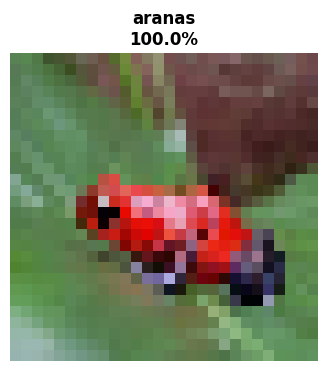

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 55: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana3.jpg


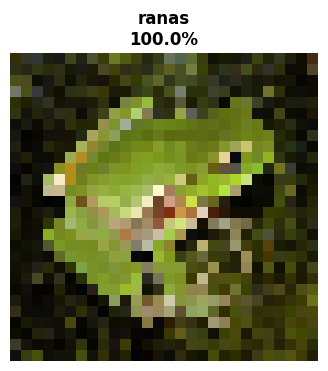

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 56: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana4.jpg


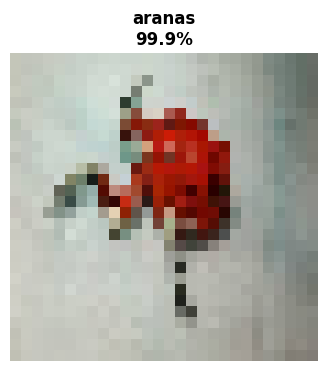

Resultado: ARANAS (99.9%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.1% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :  99.9% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

ðŸ” Procesando imagen 57: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana5.jpg


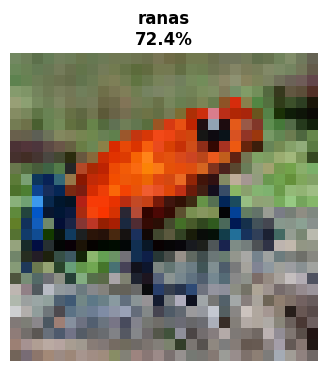

Resultado: RANAS (72.4%)
   Probabilidades:
   ranas     :  72.4% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :  27.6% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 58: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana6.jpg


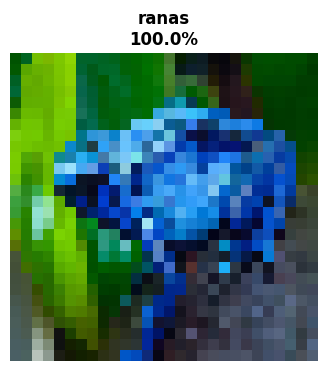

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 59: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana7.jpg


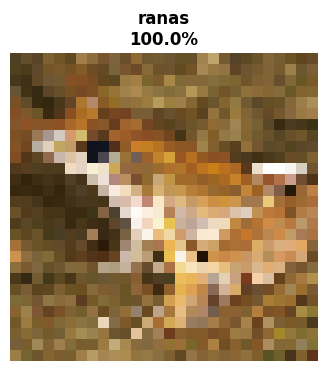

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 60: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana8.jpg


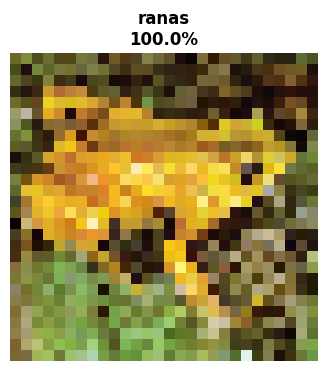

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 61: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana9.jpg


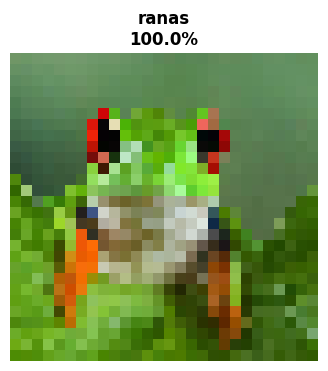

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 62: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana10.jpg


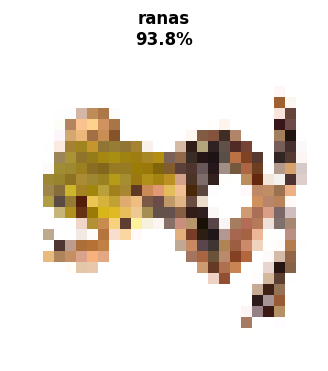

Resultado: RANAS (93.8%)
   Probabilidades:
   ranas     :  93.8% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   6.2% â–ˆ

ðŸ” Procesando imagen 63: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana11.jpg


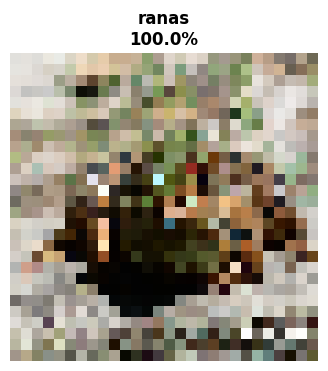

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 64: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana12.jpg


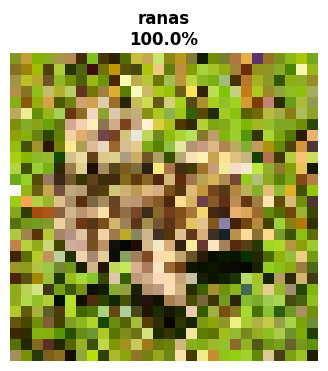

Resultado: RANAS (100.0%)
   Probabilidades:
   ranas     : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    :   0.0% 

ðŸ” Procesando imagen 65: C:/Users/Legion/OneDrive/Escritorio/dataset-video/animales_prueba/animales_prueba/rana13.jpg


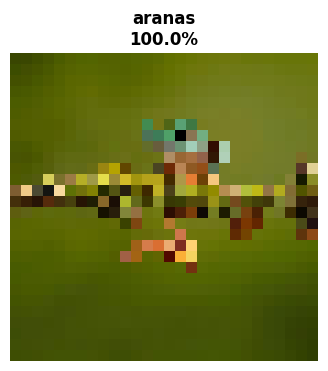

Resultado: ARANAS (100.0%)
   Probabilidades:
   ranas     :   0.0% 
   pajaros   :   0.0% 
   ballenas  :   0.0% 
   changos   :   0.0% 
   aranas    : 100.0% â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ


In [138]:
# =============================================
#   PREDICCIÃ“N CON SELECTOR DE MÃšLTIPLES IMÃGENES
# =============================================
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Abrir ventana para seleccionar mÃºltiples imÃ¡genes
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

imagenes = filedialog.askopenfilenames(
    title="Selecciona una o varias imÃ¡genes",
    filetypes=[
        ("ImÃ¡genes", "*.jpg *.jpeg *.png *.bmp *.tiff"),
        ("Todos los archivos", "*.*")
    ]
)

root.destroy()

# Verificar si se seleccionaron imÃ¡genes
if not imagenes:
    print(" No seleccionaste ninguna imagen.")
else:
    print(f"“‚ {len(imagenes)} imagen(es) seleccionada(s)\n")

    # Recorrer cada imagen
    for i, ruta in enumerate(imagenes):
        print(f"\nðŸ” Procesando imagen {i+1}: {ruta}")

        img = cv2.imread(ruta, cv2.IMREAD_COLOR)

        if img is None:
            print("âŒ No se pudo leer la imagen.")
            continue

        # Redimensionar
        img_resized = cv2.resize(img, (28, 28))

        # Preparar para el modelo
        img_array = img_resized.astype('float32') / 255.0
        img_array = img_array.reshape(1, 28, 28, 3)

        # Predecir
        prediccion = sport_model.predict(img_array, verbose=0)
        clase_idx  = np.argmax(prediccion)
        confianza  = prediccion[0][clase_idx] * 100

        # Mostrar imagen
        plt.figure(figsize=(4, 4))
        plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        plt.title(
            f'{clases_nombres[clase_idx]}\n{confianza:.1f}%',
            fontsize=12,
            fontweight='bold'
        )
        plt.axis('off')
        plt.show()

        # Consola
        print(f'Resultado: {clases_nombres[clase_idx].upper()} ({confianza:.1f}%)')

        print('   Probabilidades:')
        for clase, prob in zip(clases_nombres, prediccion[0]):
            barra = 'â–ˆ' * int(prob * 30)
            print(f'   {clase:<10}: {prob*100:5.1f}% {barra}')